In [784]:
import numpy as np
import matplotlib.pyplot as plt
import tme2
from mltools import plot_data, plot_frontiere, make_grid, gen_arti
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Test functions

In [785]:
np.random.choice([-1,1],10)

array([ 1,  1, -1, -1,  1, -1,  1,  1, -1,  1])

In [786]:
tme2.check_fonctions()
# tme2.grad_check(tme2.mse, tme2.mse_grad)
# tme2.grad_check(tme2.reglog, tme2.reglog_grad)
print("Success!")

Success!


# Experiments

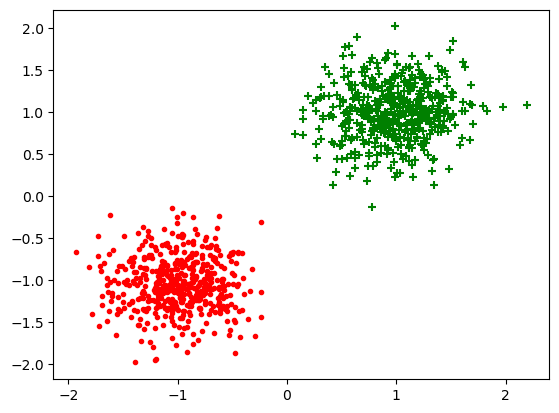

In [787]:
datax, datay = gen_arti(nbex=1000, data_type=0, epsilon=0.02)
plot_data(datax, datay)

## Linear regression

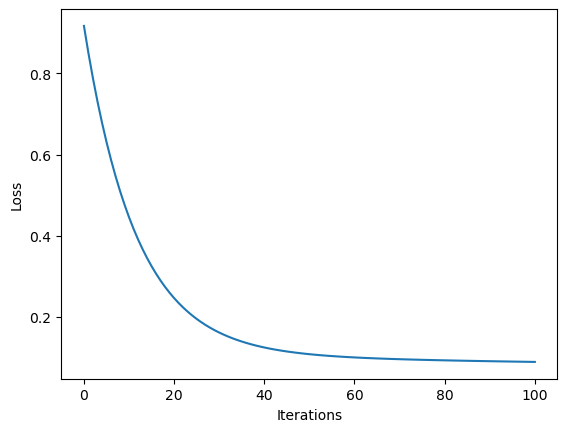

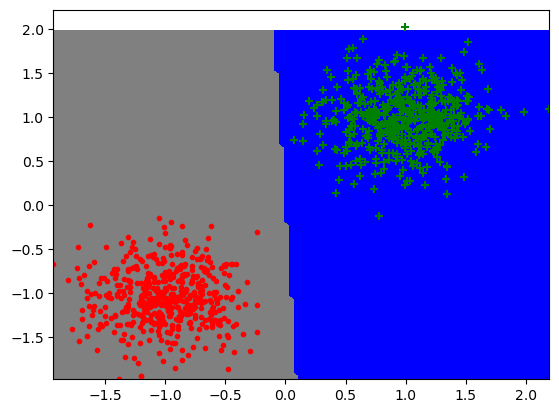

In [788]:
w, ws, losses = tme2.descente_gradient(datax, datay, 
                       f_loss=tme2.mse, 
                       f_grad= tme2.mse_grad,
                       eps=0.01,
                       iter=100)
plt.plot(range(len(losses)), losses)
plt.ylabel("Loss")
plt.xlabel("Iterations")
plt.show()
plot_frontiere(datax, lambda x: np.sign( x@w), step=100)
plot_data(datax, datay)
plt.show()

## Logistic regression

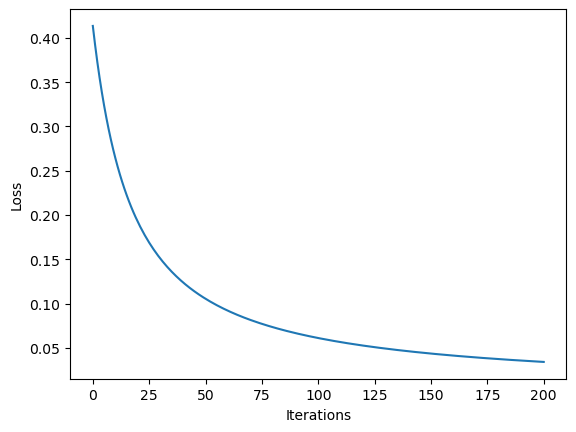

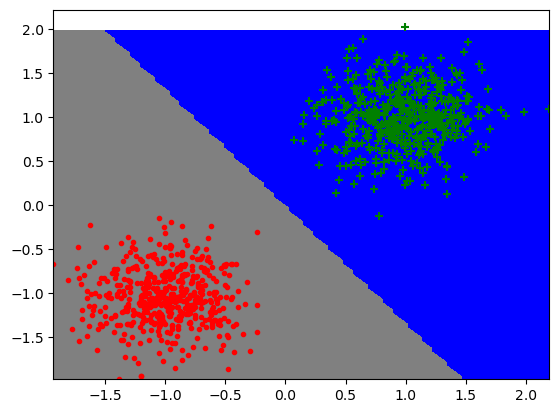

In [789]:
w, ws, losses = tme2.descente_gradient(datax, datay, 
                       f_loss=tme2.reglog, 
                       f_grad= tme2.reglog_grad,
                       eps=0.1,
                       iter=200)
plt.plot(range(len(losses)), losses)
plt.ylabel("Loss")
plt.xlabel("Iterations")
plt.show()
plot_frontiere(datax, lambda x: np.sign( tme2.sigmoid(x@w) - 0.5), step=100)
plot_data(datax, datay)
plt.show()

# Noisy and non linearly separable data

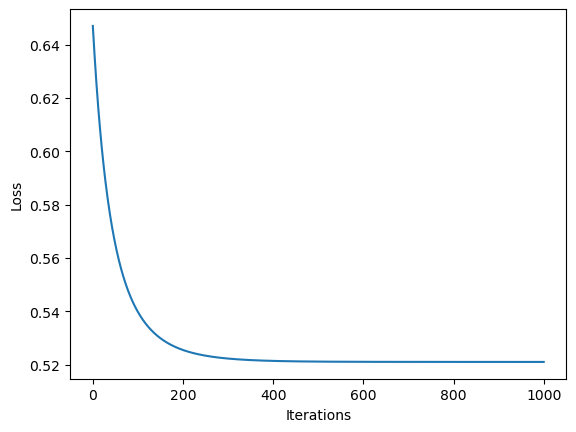

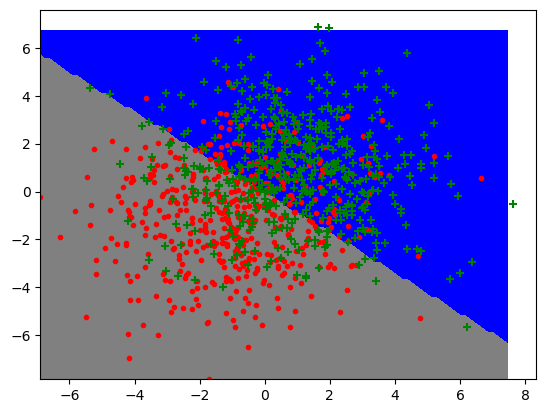

In [790]:
datax, datay = gen_arti(nbex=1000, data_type=0, epsilon=2) # play with epsilon and data type

w, ws, losses = tme2.descente_gradient(datax, datay, 
                       f_loss=tme2.reglog, 
                       f_grad= tme2.reglog_grad,
                       eps=0.01, # play with learning rate
                       iter=1000)
plt.plot(range(len(losses)), losses)
plt.ylabel("Loss")
plt.xlabel("Iterations")
plt.show()
plot_frontiere(datax, lambda x: np.sign( tme2.sigmoid(x@w) - 0.5), step=100)
plot_data(datax, datay)
plt.show()

# Visualize gradient descent

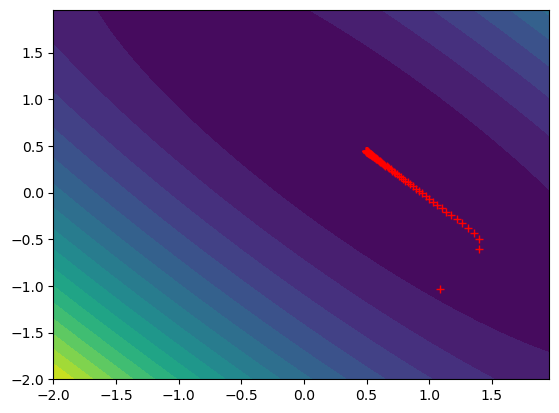

In [791]:

datax, datay = gen_arti(nbex=1000, data_type=0, epsilon=0.2)

f_loss=tme2.mse
f_grad= tme2.mse_grad

# f_loss=tme2.reglog
# f_grad= tme2.reglog_grad

w, ws, losses = tme2.descente_gradient(datax, datay, 
                       f_loss=f_loss, 
                       f_grad= f_grad,
                       eps=0.2, 
                       iter=100)

grid, x_grid, y_grid = make_grid(xmin=-2, xmax=2, ymin=-2, ymax=2, step=100)
plt.figure()
plt.contourf(x_grid,y_grid,np.array([f_loss(w,datax,datay).mean() for w in grid]).reshape(x_grid.shape),levels=20)
plt.plot(ws[:,0], ws[:,1],"+", c="red")